# Wine Quality Prediction
### Oasis Infobyte Data Analytics Internship — Level 2, Project 1
**Author:** Nandi  
**Date:** May 2026  
**Dataset:** Wine Quality Dataset (Kaggle)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('WineQT.csv')
df.head()

## 1️⃣ Data Exploration & Cleaning

In [10]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())
df.describe()

(1143, 12)
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
125


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 2️⃣ Data Visualization

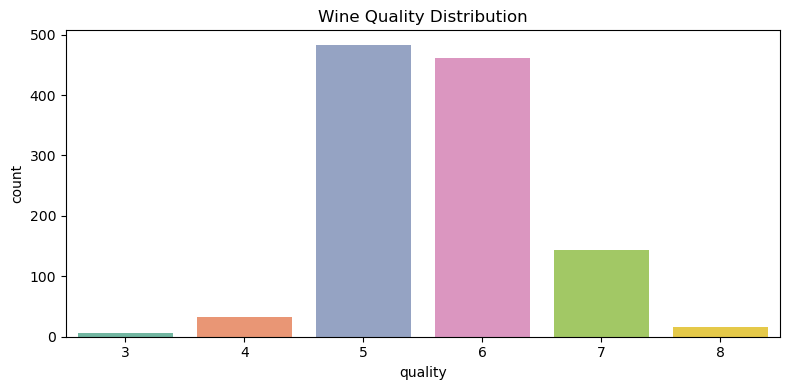

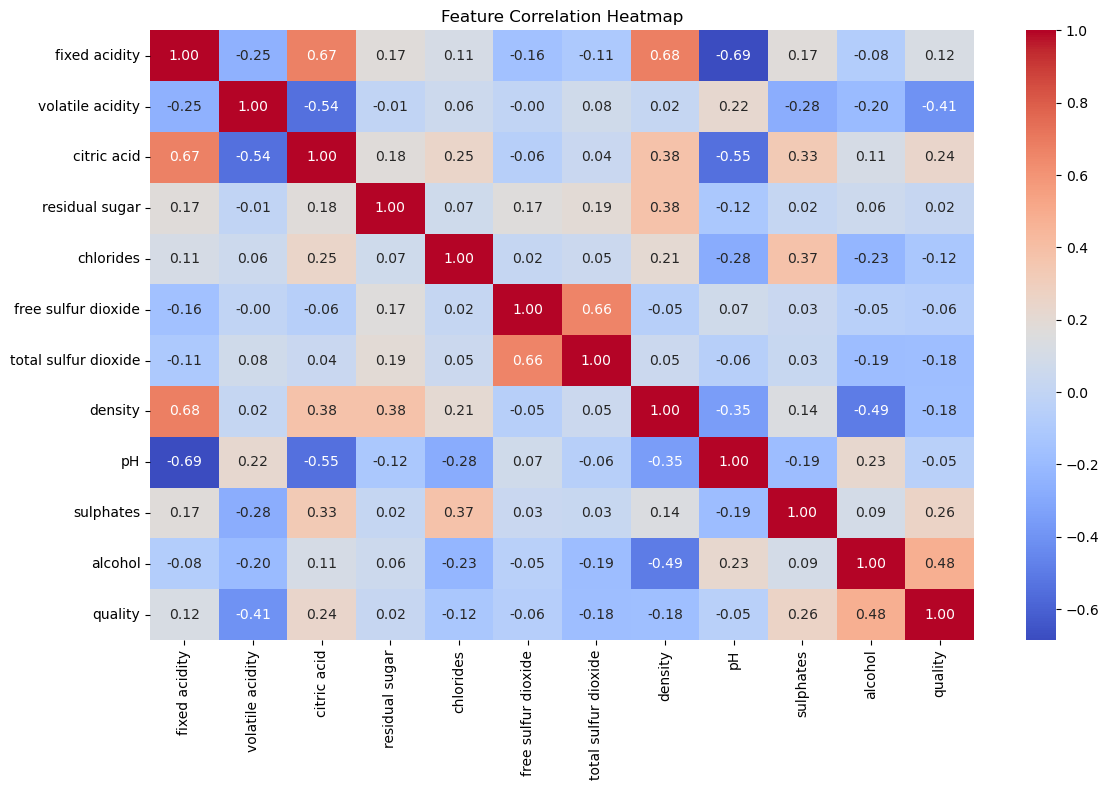

In [11]:
# Quality distribution
plt.figure(figsize=(8,4))
sns.countplot(x='quality', data=df, hue='quality', palette='Set2', legend=False)
plt.title('Wine Quality Distribution')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 3️⃣ Data Preprocessing

# Drop Id column
df = df.drop('Id', axis=1)

# Features and target
X = df.drop('quality', axis=1)
y = df['quality']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

## 4️⃣ Model Training & Evaluation

In [12]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_acc*100, 2), "%")

# SGD Classifier
sgd = SGDClassifier(random_state=42)
sgd.fit(X_train, y_train)
sgd_pred = sgd.predict(X_test)
sgd_acc = accuracy_score(y_test, sgd_pred)
print("SGD Classifier Accuracy:", round(sgd_acc*100, 2), "%")

# SVC
svc = SVC(random_state=42)
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)
svc_acc = accuracy_score(y_test, svc_pred)
print("SVC Accuracy:", round(svc_acc*100, 2), "%")

Random Forest Accuracy: 69.87 %
SGD Classifier Accuracy: 50.22 %
SVC Accuracy: 63.76 %


## 5️⃣ Model Comparison & Visualization

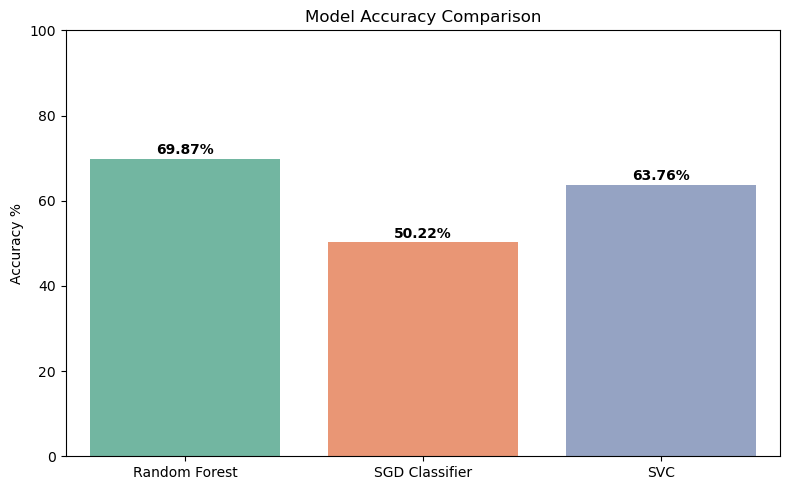

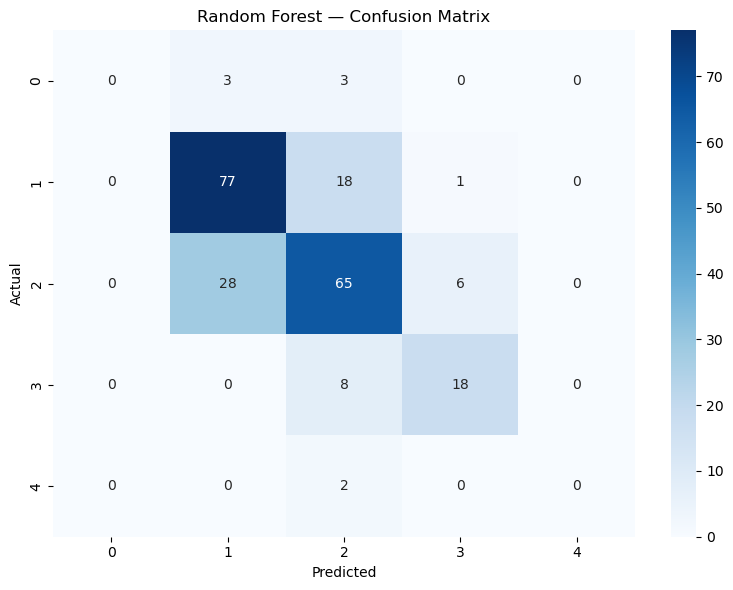

In [13]:
# Compare models
models = ['Random Forest', 'SGD Classifier', 'SVC']
accuracies = [rf_acc*100, sgd_acc*100, svc_acc*100]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies, hue=models, palette='Set2', legend=False)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy %')
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v+1, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Confusion matrix for best model (Random Forest)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 6️⃣ Conclusion & Recommendations

- 🏆 **Best Model: Random Forest** with 69.87% accuracy
- 📉 **SGD Classifier** performed the worst at 50.22% — not suitable for this dataset
- 📊 **SVC** performed decently at 63.76% but still behind Random Forest
- 🍷 **Key Features**: Alcohol content, sulphates and volatile acidity are the strongest predictors of wine quality
- 🔧 **Recommendations**: Random Forest can be further improved with hyperparameter tuning to achieve higher accuracy

## ✅ Conclusion
Three classifier models were trained and evaluated on the Wine Quality dataset. Random Forest outperformed both SGD and SVC classifiers, making it the best model for predicting wine quality based on chemical characteristics.